In [6]:
from koala.lattice import Lattice
import numpy as np
import numpy.typing as npt
from koala.flux_finder import fluxes_from_ujk, ujk_from_fluxes
from koala import graph_utils as gu
from koala import example_graphs as eg
from koala.flux_finder import ujk_from_fluxes, fluxes_from_ujk
from koala import plotting as pl

from pfapack.ctypes import pfaffian
import pfapack.ctypes as cpf
import ctypes
from scipy import linalg as la
from matplotlib import pyplot as plt
from dimer_models.lattice_generation import expand_edges_to_squares
from dimer_models.kasteleyn import kasteleyn_matrix, _fast_pfaffian

In [7]:
def k_ham_generator(lattice, hamiltonian):
    """
    Adds momentum dependence to a given lattice and Hamiltonian.

    Parameters:
    - lattice: An instance of Lattice.
    - hamiltonian: A function that takes a pair of vertices and returns the weight of the edge between them.

    Returns:
    - A momentum-dependent matrix for the lattice.
    """

    def k_hamiltonian(k: np.ndarray):

        # k = np.asarray(k, dtype=np.complex128)
        cross = lattice.edges.crossing
        phases = np.sum(cross * k, axis=-1)

        h = np.array(hamiltonian, dtype=np.complex128)
        h[lattice.edges.indices[:, 1], lattice.edges.indices[:, 0]] *= np.exp(
            1j * phases
        )
        h[lattice.edges.indices[:, 0], lattice.edges.indices[:, 1]] *= np.exp(
            -1j * phases
        )

        return h

    return k_hamiltonian


def hex_with_every_other(n, every_other, return_lat_and_mask=False):
    center = 0.5 + 1 / (4 * n)
    lattice = eg.honeycomb_lattice(n)
    edge_centers = np.mean(lattice.vertices.positions[lattice.edges.indices], axis=1)

    # kitaev edge labels
    edge_angles = np.arctan2(*lattice.edges.vectors.T) % np.pi
    _, edge_labels = np.unique(np.round(edge_angles, 2), return_inverse=True)

    # Create a mask for edges that are chosen
    vert_edge_centers = edge_centers[edge_labels == 0]
    _, edge_column = np.unique(vert_edge_centers[:, 0], return_inverse=True)
    print(len(_))

    mask = np.zeros(lattice.n_edges, dtype=bool)
    mask[edge_labels == 0] = edge_column % every_other == 0
    mask = mask * (edge_labels == 0)  # Only keep edges with label 0
    out = expand_edges_to_squares(lattice, np.where(mask)[0])
    if return_lat_and_mask:
        return out, lattice, mask

    return out

fluxes[-1 -1 -1]
total is: 4.00000e+00
all: [0. 4. 0. 4.]
total is: 4.000000e+00
Nex, Nox is: 2.0 2.0
Ney, Noy is: 4.0 0.0
Nex/Nox is:  1.000000 or  1.000000
Ney/Noy is:  0.000000 or      inf


/var/folders/v4/z7wcc4gj6clczcj6vr8b9dvw0000gn/T/ipykernel_88094/1553087605.py:64: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"Ney/Noy is: {Noy / Ney: 8f} or {Ney / Noy: 8f}")


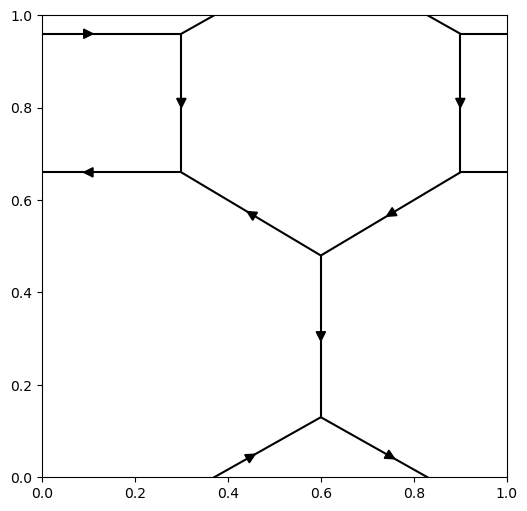

In [ ]:
from dimer_models.kasteleyn import find_kasteleyn_number


# mini_lattice = eg.hex_square_oct_lattice(1)
# shift = np.array([0.1, 0.31])
# data = mini_lattice.compact_rep
# for vertex in range(mini_lattice.n_vertices):
#     data = gu.shift_vertex((*data,mini_lattice.vertices.adjacent_edges), vertex, shift)
# mini_lattice = Lattice(*data)

# semi squoctagon
# mini_lattice = eg.honeycomb_lattice(20)
# edge_angles = np.arctan2(*mini_lattice.edges.vectors.T) % np.pi
# _, edge_labels = np.unique(np.round(edge_angles, 2), return_inverse=True)
# mask = edge_labels == 0
# mini_lattice = expand_edges_to_squares(mini_lattice, np.where(mask)[0])

# sqoctagon
# n_unit_cells = 1
# spacing = 1
# mini_lattice = hex_with_every_other(n_unit_cells * spacing, spacing)
# mini_lattice = gu.com_relaxation(mini_lattice)

orientation = ujk_from_fluxes(mini_lattice, [-1] * mini_lattice.n_plaquettes)
orientationfluxes = fluxes_from_ujk(mini_lattice, orientation)
print(f"fluxes{orientationfluxes}")
fig = plt.figure(figsize=(6, 6))
pl.plot_edges(
    mini_lattice,
    directions=orientation,
)

kast = k_ham_generator(mini_lattice, kasteleyn_matrix(mini_lattice, orientation))
# n_dimers = gu.dimerise(mini_lattice, -1).shape[0]

print(f"total is: {find_kasteleyn_number(mini_lattice):.5e}")


# plt.show()

four_sectors = [kast([0, 0]), kast([0, np.pi]), kast([np.pi, 0]), kast([np.pi, np.pi])]

nk = np.zeros(4)
powk = np.zeros(4)
for i, k in enumerate(four_sectors):
    pf = _fast_pfaffian(k.real)
    nk[i] = pf[0]
    powk[i] = pf[1]

all_pfaffians = nk * 10**powk
print(f"all: {all_pfaffians}")

Nex = (nk[2] * 10 ** powk[2] + nk[3] * 10 ** powk[3]) // 2
Nox = (-nk[0] * 10 ** powk[0] + nk[1] * 10 ** powk[1]) // 2
Ney = (nk[1] * 10 ** powk[1] + nk[3] * 10 ** powk[3]) // 2
Noy = (-nk[0] * 10 ** powk[0] + nk[2] * 10 ** powk[2]) // 2

print(
    f"total is: {(-nk[0]* 10 ** powk[0] + nk[1]* 10 ** powk[1]+ nk[2]* 10 ** powk[2]+ nk[3]* 10 ** powk[3])//2:5e}"
)
print(f"Nex, Nox is: {Nex} {Nox}")
print(f"Ney, Noy is: {Ney} {Noy}")
print(f"Nex/Nox is: {Nox / Nex: 8f} or {Nex / Nox: 8f}")
print(f"Ney/Noy is: {Noy / Ney: 8f} or {Ney / Noy: 8f}")

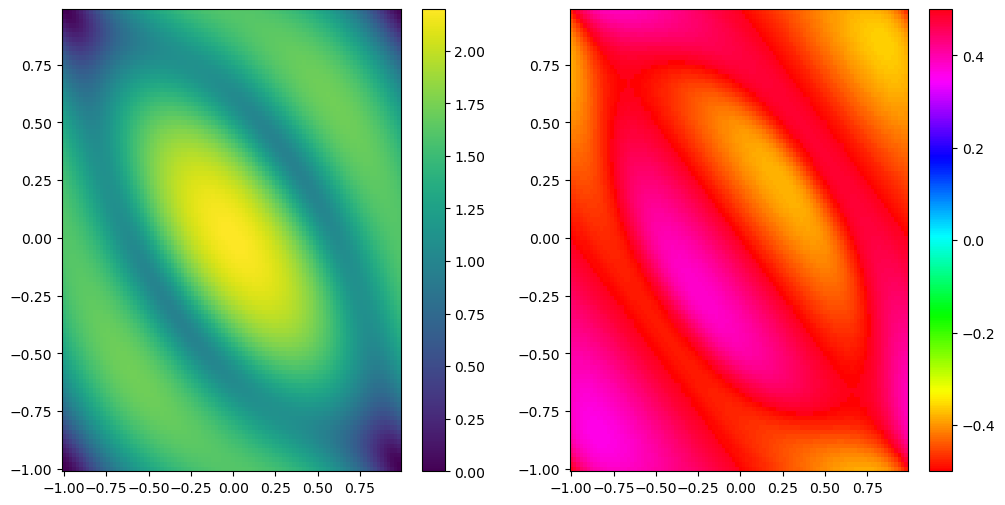

In [9]:
k_vals = np.linspace(-np.pi, np.pi, 100, endpoint=False)
KX, KY = np.meshgrid(k_vals, k_vals)

pfafs = np.zeros(KX.shape, dtype=np.complex128)
eigs = np.zeros(KX.shape, dtype=np.complex128)

for kx, ky in zip(KX.flatten(), KY.flatten()):
    k = kast([kx, ky])
    pfafs[np.where((KX == kx) & (KY == ky))] = pfaffian(k)
    # print(la.eigvalsh(k))
    # eigs[np.where((KX == kx) & (KY == ky))] = la.eigvals(k)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
y = ax[0].pcolormesh(
    KX / np.pi,
    KY / np.pi,
    np.log(np.abs(pfafs)),
)  # , cmap="Reds")
plt.colorbar(y, ax=ax[0])
x = ax[1].pcolormesh(KX / np.pi, KY / np.pi, np.angle(pfafs) / (2 * np.pi), cmap="hsv")
plt.colorbar(x, ax=ax[1])
plt.show()